# Imports

In [15]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
from functions import *

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.keras.utils.set_random_seed(42)

# Read and view data

In [2]:
train_path = "Data/train/"
test_path = "Data/test/"

# Create a training set
print("Train dataset:")
train_ds, class_names = load_images_from_dir(train_path, (48, 48), "training")

# Create a training set
print("\nValidation dataset:")
val_ds, _ = load_images_from_dir(train_path, (48, 48), "validation")

# Create a test set
print("\nTest dataset:")
test_ds, _ = load_images_from_dir(test_path, (48, 48), "")

# Check classes
print(f"\nClasses: {class_names}")

# View class names for training set
train_df = return_class_count_df(train_path)
print(f"\nTraining/Validation classes: \n{train_df}")

# View class names for test set
test_df = return_class_count_df(test_path)
print(f"\nTest classes: \n{test_df}")

# Check if the train and test data are split 80/20
print(f"\nPercentage of data in train/val dataset: {count_files(train_path) / (count_files(train_path) + count_files(test_path)):0.2f}")
print(f"Percentage of data in test dataset: {count_files(test_path) / (count_files(train_path) + count_files(test_path)):0.2f}")

Train dataset:
Found 28709 files belonging to 7 classes.
Using 22968 files for training.

Validation dataset:


E0000 00:00:1779186751.040354   49350 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Found 28709 files belonging to 7 classes.
Using 5741 files for validation.

Test dataset:
Found 7178 files belonging to 7 classes.

Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

Training/Validation classes: 
      Class  Images
0   disgust     436
1   neutral    4965
2  surprise    3171
3     happy    7215
4      fear    4097
5       sad    4830
6     angry    3995

Test classes: 
      Class  Images
0   disgust     111
1   neutral    1233
2  surprise     831
3     happy    1774
4      fear    1024
5       sad    1247
6     angry     958

Percentage of data in train/val dataset: 0.80
Percentage of data in test dataset: 0.20


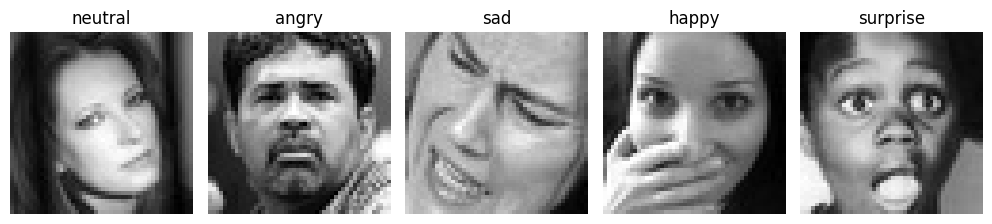

In [3]:
plot_n_images(train_ds, class_names, 5)

# Models
## Model 1

In [ ]:
model = keras.Sequential([
    layers.Input(shape=(48, 48, 1)),

    layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPool2D(pool_size=(2, 2)),

    layers.Conv2D(
        filters=64,
        kernel_size=(3, 3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPool2D(pool_size=(2, 2)),

    layers.Flatten(),

    layers.Dense(
        64,
        activation="relu"
    ),

    layers.Dense(7, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       589,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 609,159 (2.32 MB)

 Trainable params: 609,159 (2.32 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

In [6]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.3502 - loss: 1.6435 - val_accuracy: 0.4219 - val_loss: 1.5037
Epoch 2/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.4556 - loss: 1.4291 - val_accuracy: 0.4632 - val_loss: 1.3992
Epoch 3/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.4960 - loss: 1.3302 - val_accuracy: 0.4841 - val_loss: 1.3408
Epoch 4/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5241 - loss: 1.2604 - val_accuracy: 0.4828 - val_loss: 1.3404
Epoch 5/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5527 - loss: 1.1931 - val_accuracy: 0.4936 - val_loss: 1.3117
Epoch 6/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.5782 - loss: 1.1290 - val_accuracy: 0.4942 - val_loss: 1.3187
Epoch 7/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.6040 - loss: 1.0682 - val_accuracy: 0.4987 - val_loss: 1.3263
Epoch 8/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6265 - loss: 1.0080 - val_accuracy: 0.

In [7]:
print(history.history)

{'accuracy': [0.35022640228271484, 0.4556339383125305, 0.49603796005249023, 0.5240769982337952, 0.5527255535125732, 0.5782392621040344, 0.6040142774581909, 0.6265238523483276, 0.6520376205444336, 0.6744166016578674], 'loss': [1.6435236930847168, 1.4291131496429443, 1.3302042484283447, 1.2604483366012573, 1.1930543184280396, 1.1289968490600586, 1.0681670904159546, 1.0080429315567017, 0.9438042640686035, 0.8889395594596863], 'val_accuracy': [0.4218777120113373, 0.4631597399711609, 0.4840620160102844, 0.48284271359443665, 0.4936422109603882, 0.49416476488113403, 0.4986936151981354, 0.4953840672969818, 0.5006096363067627, 0.49207454919815063], 'val_loss': [1.5036519765853882, 1.3992007970809937, 1.3407955169677734, 1.3403633832931519, 1.3117027282714844, 1.3186572790145874, 1.3262994289398193, 1.3280209302902222, 1.3613698482513428, 1.4066746234893799]}


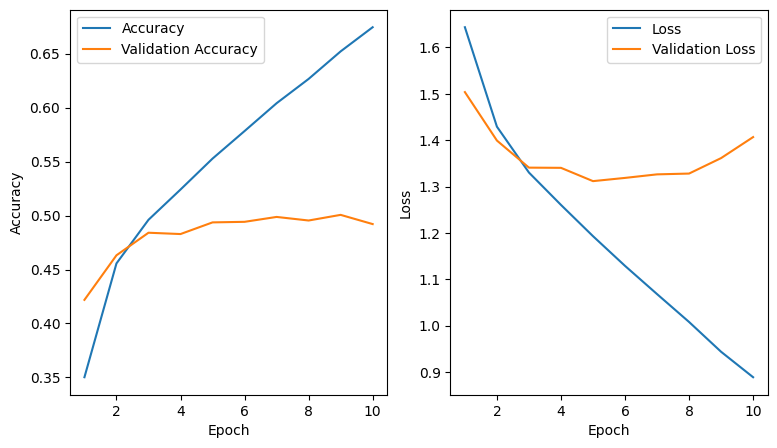

In [ ]:
plot_history_data(history.history, "Model 1 - No Regularization")

## Model 2 - Dropout

In [ ]:
model2 = keras.Sequential([
    layers.Input(shape=(48, 48, 1)),

    layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPool2D(pool_size=(2, 2)),

    layers.Conv2D(
        filters=64,
        kernel_size=(3, 3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPool2D(pool_size=(2, 2)),

    layers.Flatten(),

    layers.Dense(
        64,
        activation="relu"
    ),

    layers.Dropout(0.5),

    layers.Dense(7, activation="softmax")
])

model2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       589,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,827,479 (6.97 MB)

 Trainable params: 609,159 (2.32 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,218,320 (4.65 MB)

In [11]:
model2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

In [12]:
history2 = model2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.3038 - loss: 1.7283 - val_accuracy: 0.4116 - val_loss: 1.5396
Epoch 2/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.3891 - loss: 1.5616 - val_accuracy: 0.4424 - val_loss: 1.4937
Epoch 3/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.4124 - loss: 1.4944 - val_accuracy: 0.4569 - val_loss: 1.4002
Epoch 4/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.4370 - loss: 1.4410 - val_accuracy: 0.4762 - val_loss: 1.3663
Epoch 5/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.4556 - loss: 1.4016 - val_accuracy: 0.4785 - val_loss: 1.3410
Epoch 6/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.4647 - loss: 1.3650 - val_accuracy: 0.4900 - val_loss: 1.3267
Epoch 7/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.4774 - loss: 1.3205 - val_accuracy: 0.4990 - val_loss: 1.3100
Epoch 8/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.4951 - loss: 1.2831 - val_accuracy: 0.

In [ ]:
plot_history_data(history2.history, "Model 2 - Dropout")

TypeError: plot_history_data() takes 1 positional argument but 2 were given